# HowHotWasIt — ERA5-Land baseline vs IFS-HRES forecast bias study

> **This notebook is the definitive document for this experiment.** Findings 1 & 2
> (data bugs) are also logged in `FINDINGS.md`; how-to-run is in `README.md`.

**Question.** The app ranks an HRES forecast value against an ERA5-Land climatology (the archive tier). Any systematic offset between the two products becomes a *fake percentile signal* — "windier than 98% of days" with no meteorological cause. This notebook quantifies that offset per variable and per regime on a 20-cell pilot.

**Data.** `data/overlap.csv` — tidy long format, 20 stratified cells, 2-year daily overlap window.
- `baseline` = the **archive** tier (our ERA5-Land zarr pull, all 4 vars), read from the R2 objects.
- `hres` = **IFS-HRES historical** (`historical-forecast-api`), the settled-date proxy for the forecast tier, at the *identical* snapped 0.1° point (`cell_selection=nearest`).

**Convention.** `diff = hres - baseline`. Positive ⇒ forecast reads **high** vs the climatology it is ranked against.

---

### ⚠️ What the `hres` column actually is — read before trusting any number

The `hres` side is **not ground truth and not a reanalysis.** `historical-forecast-api` archives **what the IFS model produced** — it stitches together the **short-lead (≈0–24 h) forecast** valid on each past date. So every `hres` value carries *two* error sources baked in:

1. **Model bias** — IFS's permanent systematic tendencies (drizzle over-production, wind-tail behaviour, orographic temperature offsets). This is the signal we *want* to measure.
2. **Short-lead forecast error** — it is still a forecast, not the observed state, so there is residual noise vs. what actually happened.

Neither side of `diff` is a perfect observation. Practical reliability of the comparison, by variable:

| var | trust | why |
|-----|-------|-----|
| **tmax / tmin** | ✅ solid | short-lead IFS temperature is close to truth; bias numbers are meaningful |
| **wind_max** | ⚠️ moderate | decent at short lead; the tail is noisier |
| **precip** | ❗ directional only | IFS over-triggers light convection (too many drizzle days) and clips heavy tails; convective placement is approximate even at short lead. Neither side is truth, and disagreement is largest exactly where rain is hardest (tropics/convective). **Do not read precip "bias" as authoritative** — read it as "two imperfect estimates disagreeing." |

True ground truth would require **station observations** (GHCN-Daily / SYNOP) — a much larger build, not done here.

---

**Known archive data bugs found during this study (see `FINDINGS.md`):**
- **F1 — coastal empty cells:** ERA5-Land is land-only; coastal cities can snap to an offshore (NaN) grid cell, so the archive is all-empty. Fix = nearest-land snap. (Edinburgh, Wellington in this pilot; Section 0 auto-drops them.)
- **F2 — clipped boundary day:** the local-solar-day resample has no completeness guard, so the trailing local day (east of UTC) past the UTC data frontier is built from a partial day and written as if complete (e.g. Beijing's `2026-05-01` tmax = 15.5 °C, a pre-dawn-only value).

**Hypotheses under test** (from the briefing):
- **H1** Tmax/Tmin agree within ±0.5°C on flat mid-latitude inland.
- **H2** Tmin noisier than Tmax; warm bias on stable nights / high-latitude winter.
- **H3** Mountain cells off 1–2°C from orography mismatch.
- **H4** Wind systematically high in HRES (ERA5-Land under-represents wind 20–30%).
- **H5** Wind bias worst in the tail (daily max).
- **H6** Precip: IFS drizzle inflation → wet-day frequency threshold-sensitive.
- **H7** Precip extremes clipped; tropics mostly random noise.
- **H8** *(not yet done)* internal archive→recent seam discontinuity.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'font.size': 10})

WET_MM, DRY_MM = 1.0, 0.1
df = pd.read_csv('data/overlap.csv')
df['baseline'] = pd.to_numeric(df['baseline'], errors='coerce')
df['hres'] = pd.to_numeric(df['hres'], errors='coerce')
df = df.dropna(subset=['baseline', 'hres']).copy()
df['diff'] = df['hres'] - df['baseline']
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
# northern-winter flag (DJF in N hemi, JJA in S) for stable-boundary-layer split
df['local_winter'] = np.where(df['lat'] >= 0, df['month'].isin([12,1,2]),
                              df['month'].isin([6,7,8]))
print(f"{len(df):,} paired obs · {df['name'].nunique()} cells ·",
      f"{df['date'].min().date()} .. {df['date'].max().date()}")
df.groupby('var').size()

51,829 paired obs · 20 cells · 2024-05-31 .. 2026-05-01


var
precip      14008
tmax        12607
tmin        12607
wind_max    12607
dtype: int64

## 0. Data integrity — degenerate baseline cells

**Finding (surfaced by the pilot, not expected):** some cells' *archive* objects in R2 are broken — entire variables are all-empty (tmax/tmin/wind) or all-zero (precip), giving a zero-variance climatology. Those cells would render a meaningless percentile in the live app and must be excluded from the bias stats **and re-pulled in the era5 pipeline**. We detect any (cell, var) whose `baseline` has near-zero spread and drop just that slice.

In [2]:
spread = df.groupby(['name','var'])['baseline'].std().reset_index(name='baseline_std')
bad = spread[spread['baseline_std'] < 1e-6]
if len(bad):
    print('DEGENERATE baseline slices (archive bug — re-pull these cells):')
    print(bad.to_string(index=False))
else:
    print('no degenerate baseline slices')
bad_keys = set(map(tuple, bad[['name','var']].values))
n0 = len(df)
df = df[~df.set_index(['name','var']).index.isin(bad_keys)].copy()
print(f"\ndropped {n0-len(df):,} rows from degenerate slices; {len(df):,} remain")

DEGENERATE baseline slices (archive bug — re-pull these cells):
      name    var  baseline_std
 Edinburgh precip           0.0
Wellington precip           0.0

dropped 1,401 rows from degenerate slices; 50,428 remain


## 1. Temperature bias per cell (H1 / H2 / H3)
Mean bias with ±1 std whiskers. Dashed band = the ±0.5°C "agreement" zone from H1.

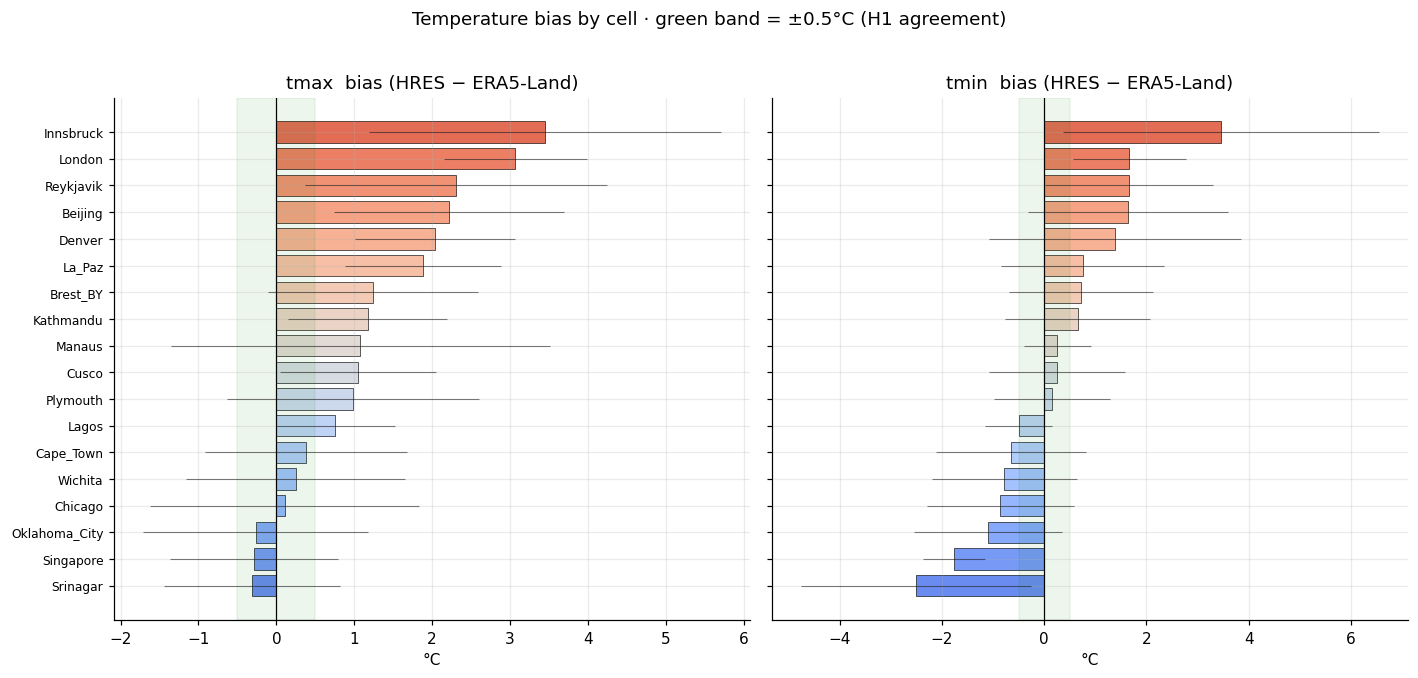

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
for ax, var in zip(axes, ['tmax', 'tmin']):
    sub = df[df['var'] == var]
    g = sub.groupby(['name', 'regime'])['diff'].agg(['mean', 'std']).reset_index()
    g = g.sort_values('mean')
    colors = plt.cm.coolwarm(np.linspace(0.15, 0.85, len(g)))
    y = np.arange(len(g))
    ax.barh(y, g['mean'], xerr=g['std'], color=colors, edgecolor='k', lw=0.4,
            error_kw=dict(lw=0.7, alpha=0.5))
    ax.axvspan(-0.5, 0.5, color='green', alpha=0.07)
    ax.axvline(0, color='k', lw=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels([f"{n}" for n in g['name']], fontsize=8)
    ax.set_title(f"{var}  bias (HRES − ERA5-Land)")
    ax.set_xlabel('°C')
fig.suptitle('Temperature bias by cell · green band = ±0.5°C (H1 agreement)', y=1.02)
plt.tight_layout(); plt.show()

In [4]:
# Numeric table: bias / rmse / std, flag H1 (flat) and H3 (mountain)
rows = []
for var in ['tmax', 'tmin']:
    for (name, regime), gg in df[df['var']==var].groupby(['name','regime']):
        rows.append(dict(var=var, cell=name, regime=regime,
                         bias=gg['diff'].mean(),
                         rmse=np.sqrt((gg['diff']**2).mean()),
                         std=gg['diff'].std()))
temp = pd.DataFrame(rows)
temp.round(2).sort_values(['var','bias'])

,var,cell,regime,bias,rmse,std
0,tmax,Beijing,flat_inland_china,-0.31,1.17,1.13
11,tmax,Manaus,tropics_amazon,-0.29,1.11,1.08
12,tmax,Oklahoma_City,great_plains,-0.27,1.47,1.44
6,tmax,Innsbruck,mountain_alps,0.11,1.73,1.72
17,tmax,Wichita,great_plains,0.25,1.43,1.40
1,tmax,Brest_BY,flat_inland,0.38,1.35,1.30
9,tmax,Lagos,tropics_monsoon,0.75,1.07,0.76
3,tmax,Chicago,flat_inland,0.98,1.89,1.62
13,tmax,Plymouth,nw_europe_coast,1.05,1.45,1.00
16,tmax,Srinagar,mountain_himalaya,1.08,2.66,2.43


## 2. Is Tmin noisier than Tmax? (H2)
RMSE of the difference, Tmax vs Tmin, per cell. Points above the diagonal = Tmin noisier.

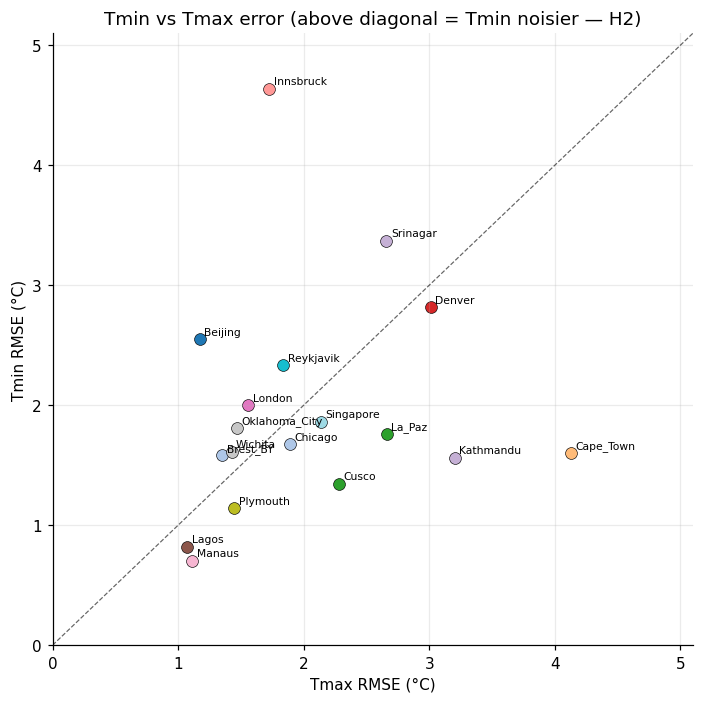

Tmin noisier than Tmax in 8/18 cells


In [5]:
piv = temp.pivot_table(index=['cell','regime'], columns='var', values='rmse').reset_index()
fig, ax = plt.subplots(figsize=(6.5, 6.5))
regimes = piv['regime'].unique()
cmap = dict(zip(regimes, plt.cm.tab20(np.linspace(0, 1, len(regimes)))))
for _, r in piv.iterrows():
    ax.scatter(r['tmax'], r['tmin'], color=cmap[r['regime']], s=60, edgecolor='k', lw=0.4)
    ax.annotate(r['cell'], (r['tmax'], r['tmin']), fontsize=7,
                xytext=(3,3), textcoords='offset points')
lim = [0, piv[['tmax','tmin']].max().max()*1.1]
ax.plot(lim, lim, 'k--', lw=0.8, alpha=0.6)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Tmax RMSE (°C)'); ax.set_ylabel('Tmin RMSE (°C)')
ax.set_title('Tmin vs Tmax error (above diagonal = Tmin noisier — H2)')
plt.tight_layout(); plt.show()
n_above = (piv['tmin'] > piv['tmax']).sum()
print(f"Tmin noisier than Tmax in {n_above}/{len(piv)} cells")

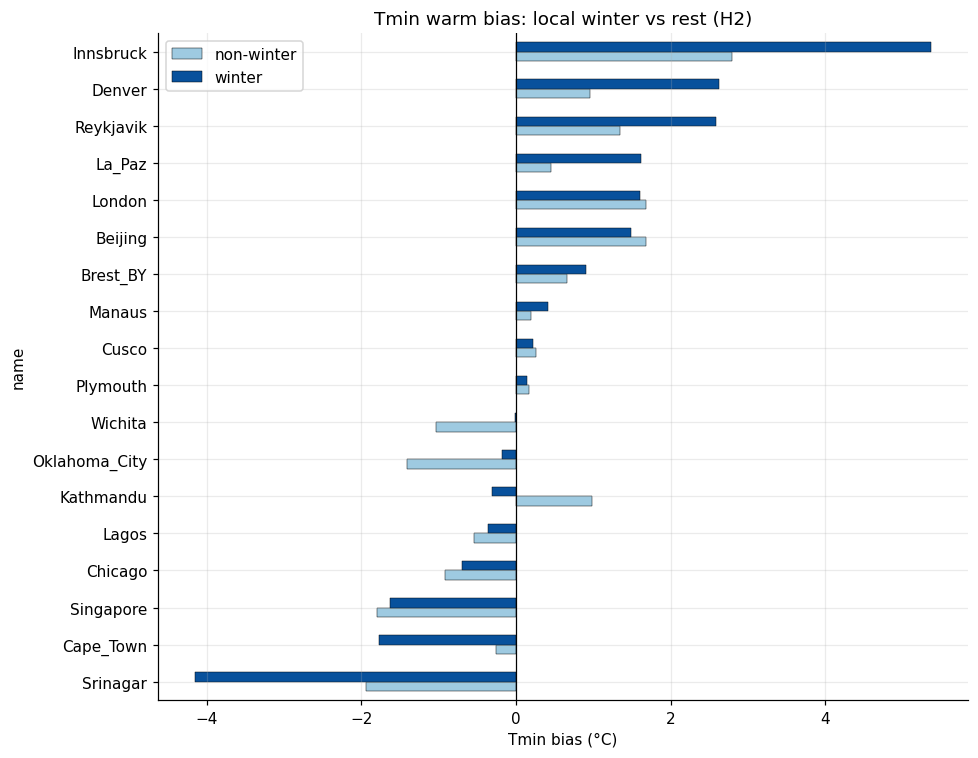

In [6]:
# H2 cont'd: is the Tmin warm bias concentrated in local winter?
tmin = df[df['var']=='tmin']
ws = tmin.groupby(['name','local_winter'])['diff'].mean().unstack()
ws.columns = ['non-winter','winter']
ws = ws.sort_values('winter')
ax = ws.plot.barh(figsize=(9,7), color=['#9ecae1','#08519c'], edgecolor='k', lw=0.3)
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('Tmin bias (°C)'); ax.set_title('Tmin warm bias: local winter vs rest (H2)')
plt.tight_layout(); plt.show()

## 3. Wind — the headline landmine (H4 / H5)
H4: ERA5-Land under-represents surface wind, HRES doesn't ⇒ ratio HRES/ERA5-Land > 1 everywhere.
H5: worst in the tail. We plot mean ratio and the p95 (tail) ratio per cell.

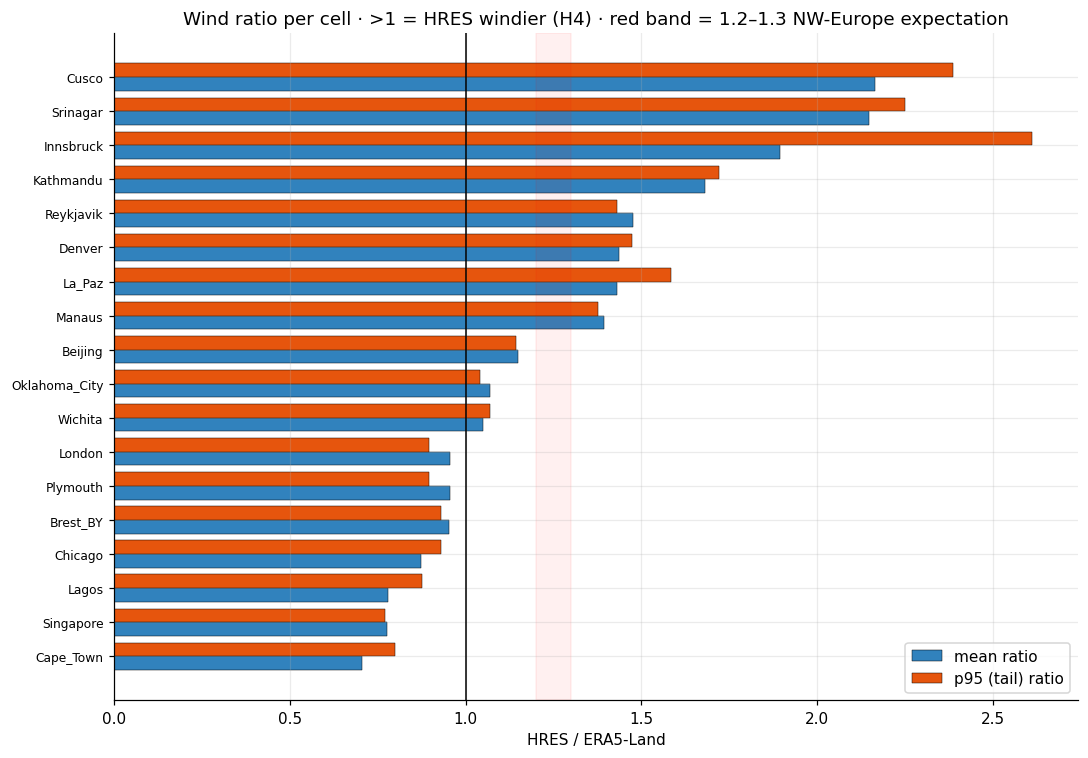

,cell,regime,mean_ratio,p95_ratio,mean_b,mean_h
2,Cape_Town,coast_storm,0.70,0.80,7.25,5.10
15,Singapore,tropics_itcz,0.78,0.77,4.49,3.48
9,Lagos,tropics_monsoon,0.78,0.88,4.48,3.49
3,Chicago,flat_inland,0.87,0.93,6.48,5.66
1,Brest_BY,flat_inland,0.95,0.93,4.59,4.37
13,Plymouth,nw_europe_coast,0.96,0.90,6.35,6.07
10,London,nw_europe,0.96,0.90,4.93,4.71
17,Wichita,great_plains,1.05,1.07,5.55,5.82
12,Oklahoma_City,great_plains,1.07,1.04,5.41,5.79
0,Beijing,flat_inland_china,1.15,1.14,3.33,3.82


In [7]:
w = df[df['var']=='wind_max']
rows = []
for (name, regime), gg in w.groupby(['name','regime']):
    rows.append(dict(cell=name, regime=regime,
                     mean_ratio=gg['hres'].mean()/gg['baseline'].mean(),
                     p95_ratio=gg['hres'].quantile(.95)/gg['baseline'].quantile(.95),
                     mean_b=gg['baseline'].mean(), mean_h=gg['hres'].mean()))
wind = pd.DataFrame(rows).sort_values('mean_ratio')

fig, ax = plt.subplots(figsize=(10, 7))
y = np.arange(len(wind))
ax.barh(y-0.2, wind['mean_ratio'], height=0.4, label='mean ratio', color='#3182bd', edgecolor='k', lw=0.3)
ax.barh(y+0.2, wind['p95_ratio'], height=0.4, label='p95 (tail) ratio', color='#e6550d', edgecolor='k', lw=0.3)
ax.axvline(1.0, color='k', lw=1)
ax.axvspan(1.2, 1.3, color='red', alpha=0.06)  # H4 NW-Europe expectation band
ax.set_yticks(y); ax.set_yticklabels(wind['cell'], fontsize=8)
ax.set_xlabel('HRES / ERA5-Land'); ax.legend()
ax.set_title('Wind ratio per cell · >1 = HRES windier (H4) · red band = 1.2–1.3 NW-Europe expectation')
plt.tight_layout(); plt.show()
wind.round(2)

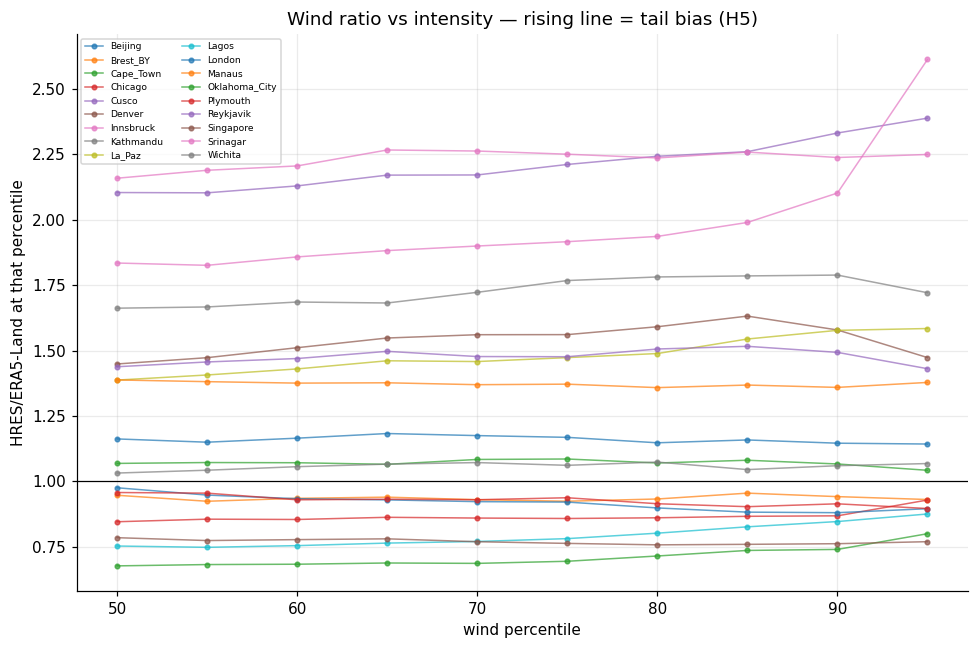

In [8]:
# H5: does the wind ratio grow with intensity? Ratio of HRES/baseline across percentiles.
qs = np.arange(0.5, 1.0, 0.05)
fig, ax = plt.subplots(figsize=(9,6))
for (name, regime), gg in w.groupby(['name','regime']):
    rb = gg['baseline'].quantile(qs).values
    rh = gg['hres'].quantile(qs).values
    ax.plot(qs*100, rh/rb, marker='.', alpha=0.7, lw=1, label=name)
ax.axhline(1, color='k', lw=0.8)
ax.set_xlabel('wind percentile'); ax.set_ylabel('HRES/ERA5-Land at that percentile')
ax.set_title('Wind ratio vs intensity — rising line = tail bias (H5)')
ax.legend(fontsize=6, ncol=2, loc='upper left')
plt.tight_layout(); plt.show()

## 4. Precipitation (H6 / H7)
H6: dry-day (<0.1mm) and wet-day (≥1mm) frequency — baseline vs HRES, per cell.
H7: p99 extremes, and the systematic:random split (tropics should be ~all random).

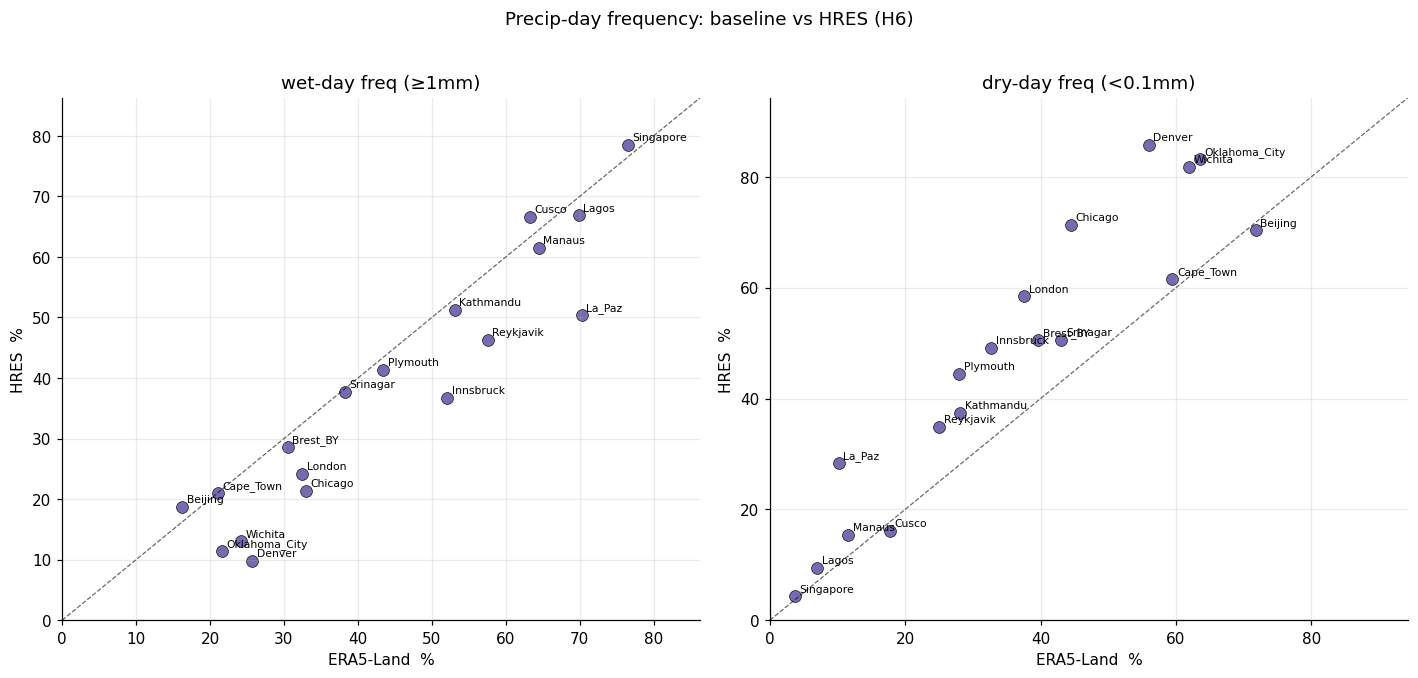

,cell,regime,dry_b,dry_h,wet_b,wet_h,p99_b,p99_h
0,Beijing,flat_inland_china,71.8,70.3,16.3,18.7,28.0,34.6
1,Brest_BY,flat_inland,39.7,50.5,30.5,28.7,14.3,17.2
2,Cape_Town,coast_storm,59.5,61.6,21.1,21.0,24.1,28.2
3,Chicago,flat_inland,44.4,71.3,33.0,21.3,28.0,35.0
4,Cusco,mountain_andes,17.7,16.1,63.3,66.6,18.0,20.3
5,Denver,mountain,56.0,85.7,25.7,9.9,13.8,16.6
6,Innsbruck,mountain_alps,32.7,49.1,52.1,36.7,28.8,26.9
7,Kathmandu,mountain_himalaya,28.1,37.4,53.1,51.2,82.9,65.9
8,La_Paz,mountain_andes,10.1,28.3,70.3,50.4,20.0,16.1
9,Lagos,tropics_monsoon,7.0,9.4,69.9,66.9,23.9,25.9


In [9]:
p = df[df['var']=='precip']
rows = []
for (name, regime), gg in p.groupby(['name','regime']):
    rows.append(dict(cell=name, regime=regime,
        dry_b=(gg['baseline']<DRY_MM).mean()*100, dry_h=(gg['hres']<DRY_MM).mean()*100,
        wet_b=(gg['baseline']>=WET_MM).mean()*100, wet_h=(gg['hres']>=WET_MM).mean()*100,
        p99_b=gg['baseline'].quantile(.99), p99_h=gg['hres'].quantile(.99)))
prec = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, (lo, hi, title) in zip(axes, [('wet_b','wet_h','wet-day freq (≥1mm)'),
                                       ('dry_b','dry_h','dry-day freq (<0.1mm)')]):
    ax.scatter(prec[lo], prec[hi], s=60, edgecolor='k', lw=0.4, c='#756bb1')
    for _, r in prec.iterrows():
        ax.annotate(r['cell'], (r[lo], r[hi]), fontsize=7, xytext=(3,3), textcoords='offset points')
    m = max(prec[lo].max(), prec[hi].max())*1.1
    ax.plot([0,m],[0,m],'k--',lw=0.8,alpha=0.6); ax.set_xlim(0,m); ax.set_ylim(0,m)
    ax.set_xlabel(f'ERA5-Land  %'); ax.set_ylabel('HRES  %'); ax.set_title(title)
fig.suptitle('Precip-day frequency: baseline vs HRES (H6)', y=1.02)
plt.tight_layout(); plt.show()
prec.round(1)

## 5. Systematic vs random split (which biases are even correctable?)
`|bias| / rmse` near 1 ⇒ mostly systematic ⇒ a per-cell correction helps.
Near 0 ⇒ mostly random noise (ECMWF's tropics caveat) ⇒ correction barely helps.

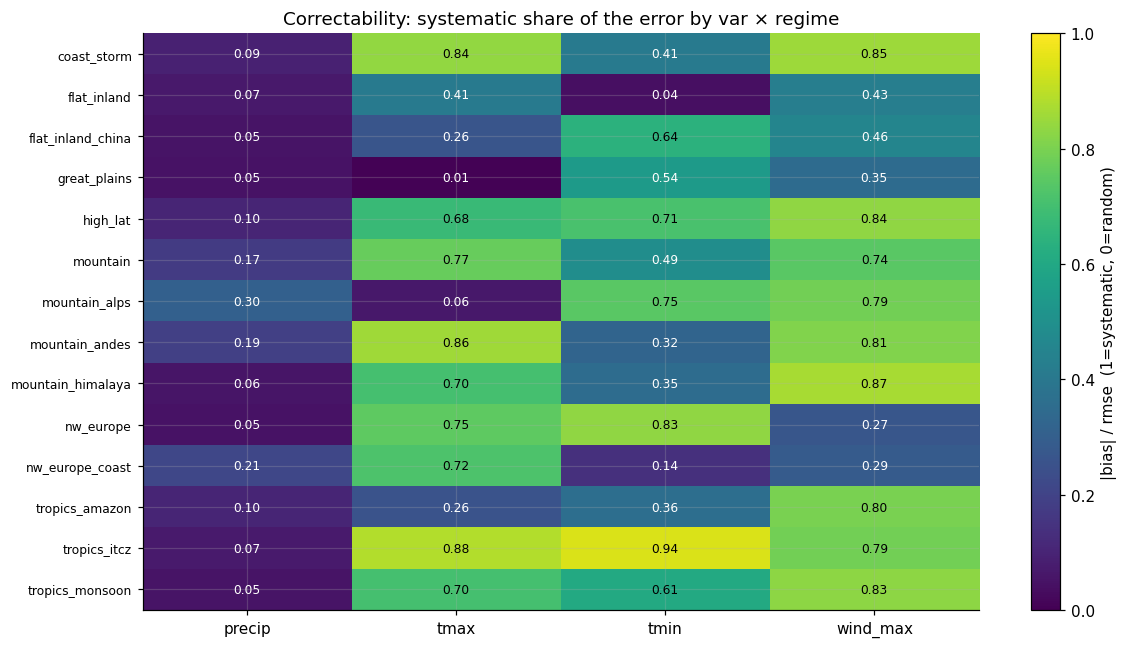

In [10]:
rows = []
for var in ['tmax','tmin','precip','wind_max']:
    for regime, gg in df[df['var']==var].groupby('regime'):
        bias = gg['diff'].mean(); rmse = np.sqrt((gg['diff']**2).mean())
        rows.append(dict(var=var, regime=regime, bias=bias, rmse=rmse,
                         ratio=abs(bias)/rmse if rmse else np.nan, n=len(gg)))
split = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(11,6))
piv = split.pivot(index='regime', columns='var', values='ratio')
im = ax.imshow(piv.values, cmap='viridis', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index, fontsize=8)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i,j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    color='white' if v<0.6 else 'black', fontsize=8)
fig.colorbar(im, label='|bias| / rmse  (1=systematic, 0=random)')
ax.set_title('Correctability: systematic share of the error by var × regime')
plt.tight_layout(); plt.show()

## 6. The number that matters: percentile-points moved (Phase 3)
For each cell×var, take the HRES **p90** value and ask where it ranks in the **baseline** climatology vs the **HRES** climatology. The gap is exactly the headline distortion a user sees ("windier than X% of days").

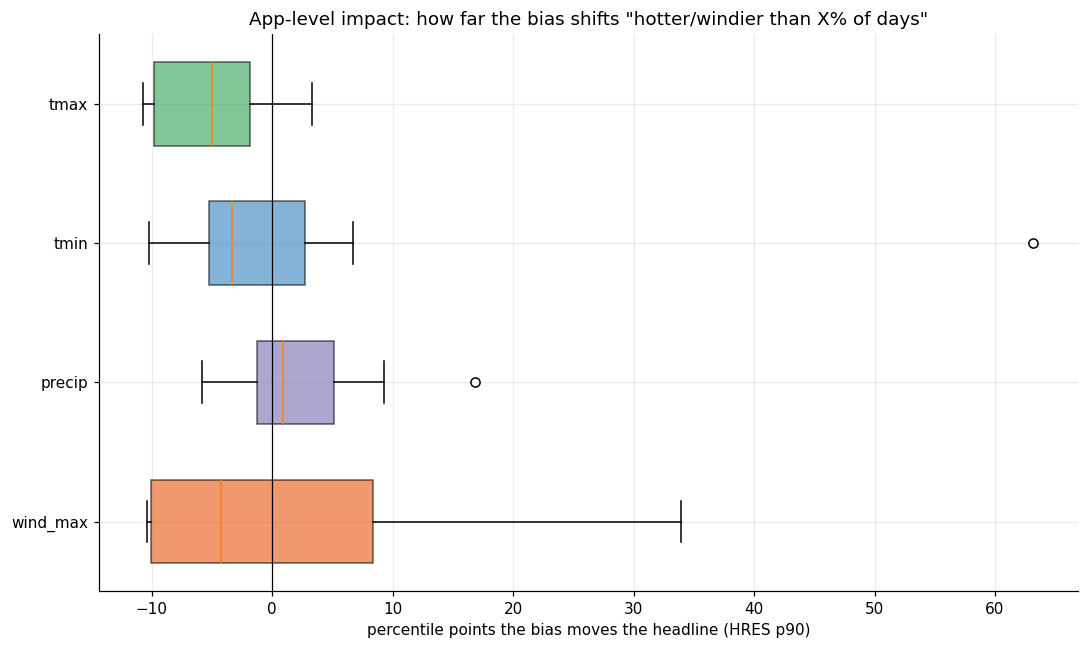

,mean,min,max
var,,,
precip,2.1,-5.8,16.9
tmax,-5.3,-10.7,3.3
tmin,1.1,-10.3,63.2
wind_max,1.8,-10.4,34.0


In [11]:
rows = []
for var in ['tmax','tmin','precip','wind_max']:
    for (name, regime), gg in df[df['var']==var].groupby(['name','regime']):
        val = gg['hres'].quantile(.90)
        pct_base = (gg['baseline'] < val).mean()*100
        pct_hres = (gg['hres'] < val).mean()*100
        rows.append(dict(var=var, cell=name, regime=regime, gap=pct_hres-pct_base))
imp = pd.DataFrame(rows)
summary = imp.groupby('var')['gap'].agg(['mean','min','max']).round(1)

fig, ax = plt.subplots(figsize=(10,6))
order = ['wind_max','precip','tmin','tmax']
data = [imp[imp['var']==v]['gap'].values for v in order]
bp = ax.boxplot(data, vert=False, tick_labels=order, patch_artist=True, widths=0.6)
for patch, c in zip(bp['boxes'], ['#e6550d','#756bb1','#3182bd','#31a354']):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('percentile points the bias moves the headline (HRES p90)')
ax.set_title('App-level impact: how far the bias shifts "hotter/windier than X% of days"')
plt.tight_layout(); plt.show()
summary

## 7. Verdict (auto-generated from the pilot)
Pass/fail against the stated thresholds. This is a 20-cell pilot — directional, not final.

In [12]:
flat = temp[temp['regime'].str.startswith('flat')]
mtn = temp[temp['regime'].str.startswith('mountain')]
print('H1  flat-inland temp |bias|<0.5°C :',
      f"mean |bias| = {flat['bias'].abs().mean():.2f}°C ->",
      'PASS' if flat['bias'].abs().mean() < 0.5 else 'FAIL')
print('H2  Tmin noisier than Tmax       :',
      f"{n_above}/{len(piv)} cells")
print('H3  mountain temp |bias| larger  :',
      f"mtn {mtn['bias'].abs().mean():.2f} vs flat {flat['bias'].abs().mean():.2f}°C")
print('H4  wind ratio >1 (HRES windier) :',
      f"{(wind['mean_ratio']>1).sum()}/{len(wind)} cells, median ratio {wind['mean_ratio'].median():.2f}")
print('H5  tail wind ratio > mean ratio :',
      f"{(wind['p95_ratio']>wind['mean_ratio']).sum()}/{len(wind)} cells")
print('Phase3 percentile pts moved      :')
print(summary.to_string())

H1  flat-inland temp |bias|<0.5°C : mean |bias| = 0.81°C -> FAIL
H2  Tmin noisier than Tmax       : 8/14 cells
H3  mountain temp |bias| larger  : mtn 1.65 vs flat 0.81°C
H4  wind ratio >1 (HRES windier) : 11/18 cells, median ratio 1.11
H5  tail wind ratio > mean ratio : 10/18 cells
Phase3 percentile pts moved      :
          mean   min   max
var                       
precip     2.1  -5.8  16.9
tmax      -5.3 -10.7   3.3
tmin       1.1 -10.3  63.2
wind_max   1.8 -10.4  34.0
